# Lab 5.2: PyTorch Lightning

**Part of the Iceland ML Course: Sentinel-2 Classification Project**

This notebook demonstrates training a classifier for remote sensing land cover classification using PyTorch Lightning.

---

## Project Context

**Inputs (From Lab 3.1):**
- Sentinel-2 patches (10 spectral bands)
- CORINE labels (12 land cover classes)
- NPZ format: combined_training_data.npz (**224x224 patches**)

**What You'll Do:**
- Build and train a CNN-based classifier
- Separate model and data logic using PyTorch-Lightning
- Organize data into PyTorch-Lightning data modules
- Generate model checkpoints for evaluation

**Output:**
- Trained model weights
- Training logs and validation metrics

## Setup and Dependencies

In [1]:
import os

from pathlib import Path

import lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import (
    DataLoader,
    Dataset,
    Subset,
    WeightedRandomSampler,
    random_split,
)
from torchvision.transforms import v2 as T
import numpy as np

from collections.abc import Mapping
from typing import Any

In [2]:
USER = os.getenv("USER")
SCRATCH = os.getenv("SCRATCH")

DATA_ROOT = Path(f"{SCRATCH}/{USER}/data")
TRAINING_DATA_DIR = DATA_ROOT / "training_data" / "Portugal_224_5labels"

assert TRAINING_DATA_DIR.exists(), TRAINING_DATA_DIR

%matplotlib inline
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [3]:
CORINE_CLASSES = {
    # Artificial surfaces (1-11)
    1: "Continuous urban fabric",
    2: "Discontinuous urban fabric",
    3: "Industrial or commercial units",
    4: "Road and rail networks",
    5: "Port areas",
    6: "Airports",
    7: "Mineral extraction sites",
    8: "Dump sites",
    9: "Construction sites",
    10: "Green urban areas",
    11: "Sport and leisure facilities",
    # Agricultural areas (12-22)
    12: "Non-irrigated arable land",
    13: "Permanently irrigated land",
    14: "Rice fields",
    15: "Vineyards",
    16: "Fruit trees and berry plantations",
    17: "Olive groves",
    18: "Pastures",
    19: "Annual crops with permanent crops",
    20: "Complex cultivation patterns",
    21: "Agriculture with natural vegetation",
    22: "Agro-forestry areas",
    # Forest and semi-natural areas (23-34)
    23: "Broad-leaved forest",
    24: "Coniferous forest",
    25: "Mixed forest",
    26: "Natural grasslands",
    27: "Moors and heathland",
    28: "Sclerophyllous vegetation",
    29: "Transitional woodland-shrub",
    30: "Beaches, dunes, sands",
    31: "Bare rocks",
    32: "Sparsely vegetated areas",
    33: "Burnt areas",
    34: "Glaciers and perpetual snow",
    # Wetlands (35-39)
    35: "Inland marshes",
    36: "Peat bogs",
    37: "Salt marshes",
    38: "Salines",
    39: "Intertidal flats",
    # Water bodies (40-44)
    40: "Water courses",
    41: "Water bodies",
    42: "Coastal lagoons",
    43: "Estuaries",
    44: "Sea and ocean",
    48: "No data",
}

# Color mapping for visualization
CORINE_COLORS = {
    1: "#E6004D",
    2: "#FF0000",
    3: "#CC4DF2",
    4: "#CC0000",
    5: "#E6CCCC",
    6: "#E6CCE6",
    7: "#A600CC",
    8: "#A64DCC",
    9: "#FF4DFF",
    10: "#FFA6FF",
    11: "#FFE6FF",
    12: "#FFFFA8",
    13: "#FFFF00",
    14: "#E6E600",
    15: "#E68000",
    16: "#F2A64D",
    17: "#E6A600",
    18: "#E6E64D",
    19: "#FFE6A6",
    20: "#FFE64D",
    21: "#E6CC4D",
    22: "#F2CCA6",
    23: "#80FF00",
    24: "#00A600",
    25: "#4DFF00",
    26: "#CCF24D",
    27: "#A6FF80",
    28: "#A6E64D",
    29: "#A6F200",
    30: "#E6E6E6",
    31: "#CCCCCC",
    32: "#CCFFCC",
    33: "#000000",
    34: "#A6E6CC",
    35: "#A6A6FF",
    36: "#4D4DFF",
    37: "#CCCCFF",
    38: "#E6E6FF",
    39: "#A6A6E6",
    40: "#00CCF2",
    41: "#80F2E6",
    42: "#00FFA6",
    43: "#A6FFE6",
    44: "#E6F2FF",
}

print(f"✓ Defined {len(CORINE_CLASSES)} CORINE land cover classes")

✓ Defined 45 CORINE land cover classes


## Custom Dataset Class

Create custom PyTorch `Dataset` and `Subset` classes for loading and splitting Sentinel-2 patches.

In [4]:
# Utils
def _parse_npz_file(file_path):
    return np.load(file_path).values()


def get_class_distribution(dataset):
    distribution = {
        label.item(): count.item()
        for label, count in zip(*dataset.labels.unique(return_counts=True))
    }
    sorted_distribution = {
        k: v
        for k, v in sorted(distribution.items(), key=lambda item: item[1], reverse=True)
    }

    return sorted_distribution

In [5]:
class CorineDataset(Dataset):
    """
    Custom Dataset for remote sensing data.

    Parameters:
    -----------
    data : torch.Tensor
        Feature data (n_samples, n_channels, patch_height, patch_width)
    labels : torch.Tensor
        Target labels (n_samples,)
    """

    def __init__(self, data, labels):

        self.original_labels = labels
        self.original_unique_labels = self.original_labels.unique()
        self.label_mapping = {
            lbl.item(): i for i, lbl in enumerate(self.original_unique_labels)
        }
        self.reverse_label_mapping = {
            i: lbl.item() for i, lbl in enumerate(self.original_unique_labels)
        }

        self.data = data
        self.labels = torch.tensor(
            [self.label_mapping[lbl.item()] for lbl in labels]
        ).type_as(self.original_labels)
        self.unique_labels = self.labels.unique()

        super().__init__()

    def drop_labels(self, blacklist, use_original=True):
        if use_original:
            blacklist = [self.reverse_label_mapping[label] for label in blacklist]
        mask = ~torch.isin(self.original_labels, torch.tensor(blacklist))
        filtered_data, filtered_orig_labels = (
            self.data[mask],
            self.original_labels[mask],
        )

        return CorineDataset(filtered_data, filtered_orig_labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        y = self.labels[idx]
        return x, y

In [6]:
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.labels = self.subset.dataset.labels[self.subset.indices]
        

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

In [7]:
file_paths = list(TRAINING_DATA_DIR.glob("*_data3.npz"))
if not file_paths:
    raise FileNotFoundError(f"No *_data.npz files found in {TRAINING_DATA_DIR}")

In [8]:
#file_paths = "/p/scratch/training2600/hilmarsson1/training_data/combined_training_data.npz"
file_paths = TRAINING_DATA_DIR.glob("*_data3.npz")

patches, labels = map(np.concatenate, zip(*map(_parse_npz_file, file_paths)))

assert patches.shape[0] == labels.shape[0]
print(patches.shape)
print(labels.shape)

(2090, 224, 224, 16)
(2090,)


In [9]:
patch_tensors = torch.tensor(patches).permute(
    0, 3, 1, 2
)  # (N, H, W, C) -> (N, C, H, W)
label_tensors = torch.tensor(labels)
raw_dataset = CorineDataset(data=patch_tensors, labels=label_tensors)

In [10]:
x, y = raw_dataset[42]
print(x.shape, y.shape)

torch.Size([16, 224, 224]) torch.Size([])


In [11]:
class_distribution = get_class_distribution(raw_dataset)

print("Labels distribution")
print(class_distribution)

print("\nMapping")
print(raw_dataset.label_mapping)

Labels distribution
{2: 1199, 1: 871, 0: 18, 3: 2}

Mapping
{1: 0, 2: 1, 3: 2, 5: 3}


In [12]:
blacklist = [idx for idx in class_distribution if class_distribution[idx] < 10]
print(blacklist)

[3]


In [13]:
filtered_dataset = raw_dataset.drop_labels(blacklist, use_original=True)

class_distribution = get_class_distribution(filtered_dataset)

print("Labels distribution")
print(class_distribution)

print("\nMapping")
print(filtered_dataset.label_mapping)

Labels distribution
{2: 1199, 1: 871, 0: 18}

Mapping
{1: 0, 2: 1, 3: 2}


In [14]:
num_classes = len(class_distribution) -1 
counts = torch.tensor([class_distribution[i] for i in range(num_classes + 1)], dtype=torch.float32)
weights = 1.0 / counts
weights = weights / weights.sum()

print(weights)

tensor([0.9656, 0.0200, 0.0145])


## Stratified splitting

Implement a stratified splitting mechanism to enforce class distribution across splits. 

A more robust solution is: [StratifiedShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedShuffleSplit.html) from `scikit-learn`.

In [15]:
def get_split(sample_indices, ratios, generator):

    from math import floor

    if len(ratios) == 2:
        _, test_ratio = ratios
        val_ratio = None
    elif len(ratios) == 3:
        _, val_ratio, test_ratio = ratios
    else:
        raise ValueError(
            "Wrong number of ratios provided. Only 2 or 3 ratio values are admitted."
        )

    num_test = max(1, floor(test_ratio * len(sample_indices)))
    num_val = max(1, floor(val_ratio * len(sample_indices))) if val_ratio else 0
    num_train = len(sample_indices) - num_test - num_val

    assert num_train + num_val + num_test == len(sample_indices), (
        "Ratios do not ensure full coverage of samples."
    )

    random_indices = torch.randperm(len(sample_indices), generator=generator)
    slices = [
        slice(0, num_train),
        slice(num_train, num_train + num_val),
        slice(num_train + num_val, num_train + num_val + num_test),
    ]
    train_indices, val_indices, test_indices = [
        sample_indices[random_indices[s]] for s in slices
    ]

    if val_indices.numel() == 0:
        return train_indices, test_indices
    return train_indices, val_indices, test_indices

In [16]:
def make_splits_train_val_test(
    dataset,
    train_frac=0.9,
    val_frac=0.05,
    test_frac=0.05,
    seed=42,
    stratify=True,
):
    """
    Train/Val/Test split with optional stratification.

    Requirements:
      train_frac + val_frac + test_frac == 1.0
    """
    total = train_frac + val_frac + test_frac
    assert abs(total - 1.0) < 1e-6, "train_frac + val_frac + test_frac must be 1.0"

    ratios = [train_frac, val_frac, test_frac]
    generator = torch.Generator().manual_seed(seed)

    if not stratify:
        train_dataset, val_dataset, test_dataset = random_split(
            dataset, ratios, generator=generator
        )
        return train_dataset, val_dataset, test_dataset

    labels = dataset.labels
    class_indices = [
        torch.argwhere(labels == label).flatten() for label in labels.unique()
    ]
    class_splits = [
        get_split(indices, ratios=ratios, generator=generator)
        for indices in class_indices
    ]
    subset_indices = map(torch.cat, zip(*class_splits))

    return [Subset(dataset, index_set) for index_set in subset_indices]

## Without data module

Split dataset and create separate data loaders.

In [17]:
train_dataset, val_dataset, test_dataset = make_splits_train_val_test(
    filtered_dataset, train_frac=0.8, val_frac=0.1, test_frac=0.1, stratify=True
)

In [18]:
def augment_training_data(dataset, train_subset, max_samples=10000, seed=0):
    """
    Offline rotation + flip augmentation applied to the training split only.

    For each generated copy: a random 90°/180°/270° rotation is applied first,
    then an independent horizontal flip (50%) and vertical flip (50%) on top.
    This gives up to 3 × 4 = 12 distinct spatial transforms per source patch.
    Val and test subsets are never touched.

    Parameters
    ----------
    dataset      : CorineDataset — the full filtered dataset before splitting
    train_subset : Subset        — training indices into dataset
    max_samples  : int           — target training-set size after augmentation
    seed         : int           — RNG seed for reproducibility

    Returns
    -------
    CorineDataset containing the augmented (and shuffled) training samples.
    """
    indices     = train_subset.indices
    # (N, C, H, W) → (N, H, W, C) for spatial transforms
    patches_chw = dataset.data[indices].numpy()
    patches_hwc = patches_chw.transpose(0, 2, 3, 1).copy()
    # Use original (unmapped) CORINE labels so CorineDataset can remap cleanly
    orig_labels = dataset.original_labels[indices].numpy()

    N = len(patches_hwc)
    print(f"Training split before augmentation: {N:,} samples")

    if N < max_samples:
        needed = max_samples - N
        print(f"  Adding {needed:,} copies (rotation + flip) to reach {max_samples:,} …")
        rng = np.random.default_rng(seed)
        aug_patches, aug_labels = [], []
        while len(aug_patches) < needed:
            batch   = min(needed - len(aug_patches), N)
            idxs    = rng.integers(0, N, size=batch)
            ks      = rng.integers(1, 4, size=batch)               # 90°, 180°, 270°
            h_flips = rng.integers(0, 2, size=batch).astype(bool)  # 50% chance
            v_flips = rng.integers(0, 2, size=batch).astype(bool)  # 50% chance
            for i, k, hf, vf in zip(idxs, ks, h_flips, v_flips):
                patch = np.rot90(patches_hwc[i], k=int(k), axes=(0, 1)).copy()
                if hf:
                    patch = np.fliplr(patch)   # flip along W axis  (H, W, C)
                if vf:
                    patch = np.flipud(patch)   # flip along H axis  (H, W, C)
                aug_patches.append(patch)
                aug_labels.append(orig_labels[i])

        patches_hwc = np.concatenate(
            [patches_hwc, np.array(aug_patches, dtype=np.float32)], axis=0
        )
        orig_labels = np.concatenate(
            [orig_labels, np.array(aug_labels, dtype=orig_labels.dtype)], axis=0
        )
    elif N > max_samples:
        print(f"  Subsampling: {N:,} → {max_samples:,}")
        idx = np.random.default_rng(seed).choice(N, max_samples, replace=False)
        patches_hwc = patches_hwc[idx]
        orig_labels = orig_labels[idx]

    # Shuffle
    idx = np.random.default_rng(seed + 1).permutation(len(orig_labels))
    patches_hwc = patches_hwc[idx]
    orig_labels = orig_labels[idx]

    # Back to (N, C, H, W) tensor
    aug_tensors      = torch.tensor(patches_hwc.transpose(0, 3, 1, 2))
    aug_label_tensor = torch.tensor(orig_labels)

    aug_dataset = CorineDataset(aug_tensors, aug_label_tensor)
    print(f"  Augmented training dataset: {len(aug_dataset):,} samples, "
          f"{len(aug_dataset.unique_labels)} classes")
    return aug_dataset


# Adjust max_samples to the desired augmented training-set size.
aug_train_dataset = augment_training_data(
    filtered_dataset, train_dataset, max_samples=10000, seed=42
)

Training split before augmentation: 1,674 samples
  Adding 8,326 copies (rotation + flip) to reach 10,000 …
  Augmented training dataset: 10,000 samples, 3 classes


In [19]:
print("Subsets summary")
print("=" * 50)

print("\nTraining set")
print("-" * 50)
print(f"# Training samples: {len(train_dataset)}")
train_labels = filtered_dataset.labels[train_dataset.indices]
print(f"# Training labels: {train_labels.unique()}")

print("\nValidation set")
print("-" * 50)
print(f"# Validation samples: {len(val_dataset)}")
val_labels = filtered_dataset.labels[val_dataset.indices]
print(f"# Validation labels: {val_labels.unique()}")

print("\nTest set")
print("-" * 50)
print(f"# Test samples: {len(test_dataset)}")
test_labels = filtered_dataset.labels[test_dataset.indices]
print(f"# Test labels: {test_labels.unique()}")

print("\nMissing classes")
unique_train_labels, unique_val_labels, unique_test_labels = [
    set(labels.unique().tolist()) for labels in (train_labels, val_labels, test_labels)
]
print(f"Val-Train: {unique_val_labels - unique_train_labels}")
print(f"Test-Train: {unique_test_labels - unique_train_labels}")
print(f"Train-Val: {unique_train_labels - unique_val_labels}")
print(f"Train-Test: {unique_train_labels - unique_test_labels}")

Subsets summary

Training set
--------------------------------------------------
# Training samples: 1674
# Training labels: tensor([0, 1, 2], dtype=torch.uint8)

Validation set
--------------------------------------------------
# Validation samples: 207
# Validation labels: tensor([0, 1, 2], dtype=torch.uint8)

Test set
--------------------------------------------------
# Test samples: 207
# Test labels: tensor([0, 1, 2], dtype=torch.uint8)

Missing classes
Val-Train: set()
Test-Train: set()
Train-Val: set()
Train-Test: set()


In [20]:
# --- 5) Sanity check label distribution ---
def label_hist(y_arr, name, topk=10):
    vals, cnts = y_arr.unique(return_counts=True)
    order = torch.argsort(cnts, descending=True)
    print(f"\n{name} label distribution (top {topk}):")
    for v, c in zip(vals[order][:topk], cnts[order][:topk]):
        orig = filtered_dataset.reverse_label_mapping[int(v)]
        print(f"  idx {int(v):2d} (CORINE {orig:2d}): {int(c)}")


label_hist(train_labels, "Train")
label_hist(val_labels, "Val")
label_hist(test_labels, "Test")


Train label distribution (top 10):
  idx  2 (CORINE  3): 961
  idx  1 (CORINE  2): 697
  idx  0 (CORINE  1): 16

Val label distribution (top 10):
  idx  2 (CORINE  3): 119
  idx  1 (CORINE  2): 87
  idx  0 (CORINE  1): 1

Test label distribution (top 10):
  idx  2 (CORINE  3): 119
  idx  1 (CORINE  2): 87
  idx  0 (CORINE  1): 1


### Transforms

In [21]:
train_transform = T.Compose(
    [
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.5),
    ]
)

### Sampler

Implement a weighted random sampler from class-specific weights

In [22]:
train_labels = aug_train_dataset.labels                   
unique_labels, counts = train_labels.unique(return_counts=True)

class_weights = torch.reciprocal(counts)
weights_dict = {k.item(): v.item() for k, v in zip(unique_labels, class_weights)}
sample_weights = torch.tensor(
    [weights_dict[label.item()] for label in train_labels], dtype=torch.float64
)

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

print(unique_labels)
print(weights_dict)

tensor([0, 1, 2], dtype=torch.uint8)
{0: 0.009900989942252636, 1: 0.00024218938779085875, 2: 0.0001733102253638208}


### Data loaders

In [23]:
train_dataloader = DataLoader(
    aug_train_dataset,                         
    sampler=weighted_sampler,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

val_dataloader = DataLoader(
    TransformedSubset(val_dataset, None),
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_dataloader = DataLoader(
    TransformedSubset(test_dataset, None),
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.5].


torch.Size([32, 16, 224, 224]) torch.Size([32])


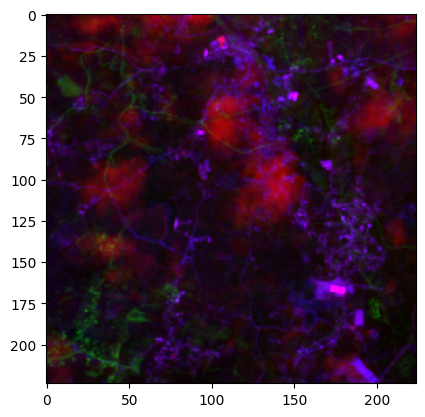

In [24]:
from matplotlib import pyplot as plt

with torch.inference_mode():
    x, y = next(iter(train_dataloader))
    print(x.shape, y.shape)
    gain = 1.5
    rgb = x[0, ...].numpy().transpose(1, 2, 0)
    rgb = np.clip(rgb[:, :, [2, 1, 0]], 0, 1)  # Ensure in [0, 1]

plt.imshow(gain * rgb)
plt.show()

## With data module

Separate data from model and training logic using a `LightningDataModule`

### Config

In [25]:
config = {
    "data": {
        "batch_size": 32,
        "train_ratio": 0.8,
        "val_ratio": 0.1,
        "test_ratio": 0.1,
        "split_strategy": "stratified",
        "sampling_strategy": "weighted",
        "transforms": {"train": None, "val": None},
    },
    "model": {"in_channels": 4, "patch_size": 32},
    "training": {"epochs": 20, "lr": 3e-4},
}

In [26]:
class CorineDataModule(pl.LightningDataModule):
    def __init__(self, dataset: Dataset, cfg: Mapping[str, Any]):
        super().__init__()
        self.dataset = dataset
        self.cfg = cfg

        split_strategy = self.cfg.get("split_strategy", None)
        if not split_strategy:
            print("Could not detect split strategy, defaulting to random splitting.")
            self.stratify = False
        elif split_strategy == "random":
            self.stratify = False
        elif split_strategy == "stratified":
            self.stratify = True
        else:
            raise ValueError(
                f"Unrecognized split strategy detected: '{split_strategy}'. Valid values are: 'random', 'stratified'."
            )

    def setup(self, stage: str):
        train_dataset, val_dataset, test_dataset = make_splits_train_val_test(
            self.dataset,
            train_frac=self.cfg["train_ratio"],
            val_frac=self.cfg["val_ratio"],
            test_frac=self.cfg["test_ratio"],
            stratify=self.stratify,
        )

        if stage == "fit":
            self.train_dataset = TransformedSubset(
                train_dataset, self.cfg["transforms"]["train"]
            )
            self.val_dataset = TransformedSubset(
                val_dataset, self.cfg["transforms"]["val"]
            )

        if stage == "test":
            self.test_dataset = TransformedSubset(
                test_dataset, self.cfg["transforms"]["val"]
            )

    def train_dataloader(self):
        sampling_strategy = self.cfg.get("sampling_strategy", None)
        if not sampling_strategy:
            print("Could not detect sampling strategy, defaulting to random sampling.")
            shuffle = True
            sampler = None
        elif sampling_strategy == "random":
            shuffle = True
            sampler = None
        elif sampling_strategy == "weighted":
            # train_labels = self.dataset.labels[self.train_dataset.subset.indices]
            train_labels = self.train_dataset.labels
            unique_labels, counts = train_labels.unique(return_counts=True)
            class_weights = torch.reciprocal(counts)
            weights_dict = {
                k.item(): v.item() for k, v in zip(unique_labels, class_weights)
            }
            sample_weights = torch.tensor(
                [weights_dict[label.item()] for label in train_labels],
                dtype=torch.float64,
            )

            print(f"Using weighted random sampling with class weights: {weights_dict}")

            shuffle = False
            sampler = WeightedRandomSampler(
                weights=sample_weights,
                num_samples=len(sample_weights),
                replacement=True,
            )
        else:
            raise ValueError(
                f"Unrecognized split strategy detected: '{sampling_strategy}'. Valid values are: 'random', 'weighted'."
            )

        return DataLoader(
            self.train_dataset,
            batch_size=self.cfg["batch_size"],
            shuffle=shuffle,
            sampler=sampler,
            num_workers=2,
            pin_memory=True,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=1,
            shuffle=False,
            num_workers=2,
            pin_memory=True,
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=1,
            shuffle=False,
            num_workers=2,
            pin_memory=True,
        )

In [27]:
datamodule = CorineDataModule(filtered_dataset, cfg=config["data"])

In [28]:
datamodule.setup(stage="fit")
train_dataset = datamodule.train_dataset
val_dataset = datamodule.val_dataset

datamodule.setup(stage="test")
test_dataset = datamodule.test_dataset

print("Subsets summary")
print("=" * 50)

print("\nTraining set")
print("-" * 50)
print(f"# Training samples: {len(train_dataset)}")
# train_labels = filtered_dataset.labels[train_dataset.indices]
train_labels = train_dataset.labels
print(f"# Training labels: {train_labels.unique()}")

print("\nValidation set")
print("-" * 50)
print(f"# Validation samples: {len(val_dataset)}")
# val_labels = filtered_dataset.labels[val_dataset.indices]
val_labels = val_dataset.labels
print(f"# Validation labels: {val_labels.unique()}")

print("\nTest set")
print("-" * 50)
print(f"# Test samples: {len(test_dataset)}")
# test_labels = filtered_dataset.labels[test_dataset.indices]
test_labels = test_dataset.labels
print(f"# Test labels: {test_labels.unique()}")

print("\nMissing classes")
unique_train_labels, unique_val_labels, unique_test_labels = [
    set(labels.unique().tolist()) for labels in (train_labels, val_labels, test_labels)
]
print(f"Val-Train: {unique_val_labels - unique_train_labels}")
print(f"Test-Train: {unique_test_labels - unique_train_labels}")
print(f"Train-Val: {unique_train_labels - unique_val_labels}")
print(f"Train-Test: {unique_train_labels - unique_test_labels}")

Subsets summary

Training set
--------------------------------------------------
# Training samples: 1674
# Training labels: tensor([0, 1, 2], dtype=torch.uint8)

Validation set
--------------------------------------------------
# Validation samples: 207
# Validation labels: tensor([0, 1, 2], dtype=torch.uint8)

Test set
--------------------------------------------------
# Test samples: 207
# Test labels: tensor([0, 1, 2], dtype=torch.uint8)

Missing classes
Val-Train: set()
Test-Train: set()
Train-Val: set()
Train-Test: set()


In [29]:
def label_hist(y_arr, name, topk=10):
    vals, cnts = y_arr.unique(return_counts=True)
    order = torch.argsort(cnts, descending=True)
    print(f"\n{name} label distribution (top {topk}):")
    for v, c in zip(vals[order][:topk], cnts[order][:topk]):
        orig = filtered_dataset.reverse_label_mapping[int(v)]
        print(f"  idx {int(v):2d} (CORINE {orig:2d}): {int(c)}")


label_hist(train_labels, "Train")
label_hist(val_labels, "Val")
label_hist(test_labels, "Test")


Train label distribution (top 10):
  idx  2 (CORINE  3): 961
  idx  1 (CORINE  2): 697
  idx  0 (CORINE  1): 16

Val label distribution (top 10):
  idx  2 (CORINE  3): 119
  idx  1 (CORINE  2): 87
  idx  0 (CORINE  1): 1

Test label distribution (top 10):
  idx  2 (CORINE  3): 119
  idx  1 (CORINE  2): 87
  idx  0 (CORINE  1): 1


In [30]:
train_loader = datamodule.train_dataloader()

Using weighted random sampling with class weights: {0: 0.0625, 1: 0.0014347202377393842, 2: 0.0010405827779322863}


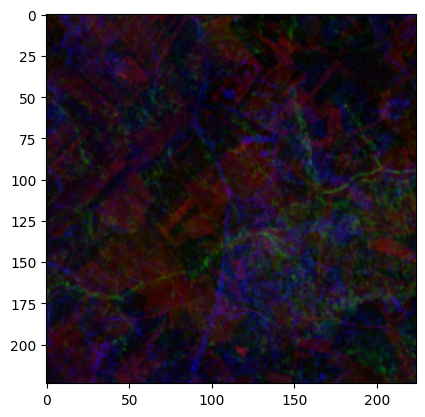

In [31]:
from matplotlib import pyplot as plt

with torch.inference_mode():
    x, y = next(iter(train_loader))
    x.size()
    gain = 1.5
    rgb = x[0, ...].numpy().transpose(1, 2, 0)
    rgb = np.clip(rgb[:, :, [2, 1, 0]], 0, 1)  # Ensure in [0, 1]

plt.imshow(gain * rgb)
plt.show()

## Model
Create the model for training.

### VGG-16

In [32]:
class VGG16(pl.LightningModule):
    """
    CNN classifier for square Sentinel-2 patches.

    Assumes flat input (B, h*w*in_channels) where spatial layout is
    channels-last: the flat was produced by X.reshape(N, -1) on an
    array of shape (N, h, w, in_channels).

    patch_size: spatial size (h = w), default 3 for 3x3 patches.
    in_channels: number of spectral bands, auto-detected in Cell 15.
    """

    def __init__(
        self,
        num_classes=10,
        in_channels=10,
        patch_size=3,
        lr=3e-4,
        max_epochs=60,
        class_weights=None,
    ):
        super().__init__()
        self.lr = lr
        self.in_channels = in_channels
        self.patch_size = patch_size
        self.num_classes = num_classes
        self.max_epochs = max_epochs

        self.features = nn.Sequential(
            # conv1: keep spatial size (3x3 → 3x3)
            nn.Conv2d(in_channels, 64, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(256, 512, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(512, 512, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding="same"),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding="same"),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        # --- INSERT THIS LINE HERE ---
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        # -----------------------------
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(25088, 4096),
            nn.ReLU(),
            nn.Linear(4096, 1000),
            nn.ReLU(),
            nn.Linear(1000, 1000),
            nn.ReLU(),
            nn.Linear(1000, num_classes),
        )

        if class_weights is not None:
            self.register_buffer("class_weights", class_weights.float())
        else:
            self.class_weights = None

    def forward(self, x):
        x = self.features(x)

        # --- INSERT THIS LINE HERE ---
        x = self.avgpool(x)
        # -----------------------------
        
        return self.classifier(x)

    def _loss(self, logits, y):
        return F.cross_entropy(logits, y, weight=self.class_weights)

    def training_step(self, batch, _):
        x, y = batch
        y = y.long()
        logits = self(x)
        loss = self._loss(logits, y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        x, y = batch
        y = y.long()
        logits = self(x)
        loss = self._loss(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
        return loss

    def test_step(self, batch, _):
        x, y = batch
        y = y.long()
        logits = self(x)
        loss = self._loss(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", acc, prog_bar=True)
        return loss

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.max_epochs)
        return {"optimizer": opt, "lr_scheduler": sched}

In [33]:
model = VGG16(
    lr=1e-5,
    num_classes=len(filtered_dataset.unique_labels),
    in_channels=16,
    patch_size=224,
    max_epochs=20,
)
print(model)

VGG16(
  (features): Sequential(
    (0): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode

In [34]:
print(len(filtered_dataset.unique_labels))

3


## Training with PyTorch Lightning

### Callbacks

[https://lightning.ai/docs/pytorch/stable/extensions/callbacks.html](https://lightning.ai/docs/pytorch/stable/extensions/callbacks.html)

In [35]:
%%time

from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, RichProgressBar

checkpoint_callback = ModelCheckpoint(
    monitor="val_acc",
    mode="max",
    dirpath=DATA_ROOT / "training_logs",
    filename="{epoch}-{val_loss:.2f}-{val_acc:.2f}",
    save_top_k=1,
)

trainer = pl.Trainer(
    accelerator="gpu",
    devices=1,
    max_epochs=20,
    log_every_n_steps=1,
    callbacks=[checkpoint_callback],
)

trainer.fit(model, train_dataloader, val_dataloader)

# ckpt_path="best" makes Lightning reload the best-val_acc checkpoint
# automatically before running the test loop.
trainer.test(model, test_dataloader, ckpt_path="best")

print(f"\nBest checkpoint: {checkpoint_callback.best_model_path}")
print(f"Best val_acc   : {checkpoint_callback.best_model_score:.4f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/p/project1/training2600/hilmarsson1/envs/ml_eo_course/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /p/scratch/training2600/hilmarsson1/data/training_logs exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3     ]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ features   │ Sequential        │ 14.7 M │ train │     0 │
│ 1 │ avgpool    │ AdaptiveAvgPool2d │      0 │ train │     0 │
│ 2 │ classifier │ Sequential        │  107 M │ train │     0 │
└───┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 122 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 122 M                                                                                                
Total estimated model params size (MB): 490                                                                        
Modules in train mode: 41                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

SLURM auto-requeueing enabled. Setting signal handlers.


Output()

...

`Trainer.fit` stopped: `max_epochs=25` reached.


Restoring states from the checkpoint path at /p/scratch/training2600/hilmarsson1/data/training_logs/epoch=13-val_loss=0.48-val_acc=0.83.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3     ]
Loaded model weights from the checkpoint at /p/scratch/training2600/hilmarsson1/data/training_logs/epoch=13-val_loss=0.48-val_acc=0.83.ckpt
SLURM auto-requeueing enabled. Setting signal handlers.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8309178948402405     │
│         test_loss         │    0.43069392442703247    │
└───────────────────────────┴───────────────────────────┘


Best checkpoint: /p/scratch/training2600/hilmarsson1/data/training_logs/epoch=13-val_loss=0.48-val_acc=0.83.ckpt
Best val_acc   : 0.8261


### Imbalance-aware validation diagnostics

Accuracy alone can be misleading on imbalanced labels. This cell reports:
- majority-class baseline
- balanced accuracy (mean recall across classes)
- macro-F1 (equal weight per class)
- per-class recall

In [36]:
from pathlib import Path
import torch

CKPT_PATH = Path("/p/scratch/training2600/hilmarsson1/data/training_logs/Model85.ckpt")

model = VGG16(
    lr=1e-5,
    num_classes=len(filtered_dataset.unique_labels),
    in_channels=16,
    patch_size=224,
    max_epochs=20,
)
ckpt = torch.load(CKPT_PATH, map_location="cpu")
model.load_state_dict(ckpt["state_dict"])
model.eval()
print(f"Loaded: {CKPT_PATH}")

Loaded: /p/scratch/training2600/hilmarsson1/data/training_logs/Model85.ckpt


In [37]:
import numpy as np
import torch


def _collect_preds_targets(model, dataloader):
    model.eval()
    device = next(model.parameters()).device
    preds_all = []
    targets_all = []
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
            targets = yb.detach().cpu().numpy()
            preds_all.append(preds)
            targets_all.append(targets)
    y_pred = np.concatenate(preds_all).astype(np.int64)
    y_true = np.concatenate(targets_all).astype(np.int64)
    return y_true, y_pred


def _confusion_matrix(y_true, y_pred):
    labels = np.unique(np.concatenate([y_true, y_pred]))
    label_to_idx = {int(lbl): i for i, lbl in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[label_to_idx[int(t)], label_to_idx[int(p)]] += 1
    return labels, cm


def _imbalanced_metrics_from_cm(cm):
    tp = np.diag(cm).astype(np.float64)
    support = cm.sum(axis=1).astype(np.float64)
    pred_count = cm.sum(axis=0).astype(np.float64)

    recall = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
    precision = np.divide(tp, pred_count, out=np.zeros_like(tp), where=pred_count > 0)
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(tp),
        where=(precision + recall) > 0,
    )

    balanced_acc = recall.mean()
    macro_f1 = f1.mean()
    overall_acc = tp.sum() / cm.sum() if cm.sum() > 0 else 0.0
    return overall_acc, balanced_acc, macro_f1, recall, precision, f1


# Evaluate on validation set
y_true_val, y_pred_val = _collect_preds_targets(model, datamodule.val_dataloader())
labels, cm = _confusion_matrix(y_true_val, y_pred_val)
overall_acc, balanced_acc, macro_f1, recall, precision, f1 = (
    _imbalanced_metrics_from_cm(cm)
)

vals, cnts = np.unique(y_true_val, return_counts=True)
majority_baseline = cnts.max() / cnts.sum()

pred_vals, pred_cnts = np.unique(y_pred_val, return_counts=True)
pred_order = np.argsort(pred_cnts)[::-1]

print("Validation diagnostics")
print("-" * 60)
print(f"Majority-class baseline acc: {majority_baseline:.4f}")
print(f"Overall accuracy:            {overall_acc:.4f}")
print(f"Balanced accuracy:           {balanced_acc:.4f}")
print(f"Macro-F1:                    {macro_f1:.4f}")

print("\nPredicted class distribution (top 10):")
for cls, c in zip(pred_vals[pred_order][:10], pred_cnts[pred_order][:10]):
    print(f"  class {int(cls):3d}: {int(c)}")

print("\nPer-class metrics:")
print("class | support | recall | precision | f1")
for i, cls in enumerate(labels):
    sup = int(cm[i].sum())
    print(
        f"{int(cls):5d} | {sup:7d} | {recall[i]:6.3f} | {precision[i]:9.3f} | {f1[i]:5.3f}"
    )

print("\nConfusion matrix (rows=true, cols=pred):")
print(cm)

Validation diagnostics
------------------------------------------------------------
Majority-class baseline acc: 0.5749
Overall accuracy:            0.8454
Balanced accuracy:           0.5654
Macro-F1:                    0.5653

Predicted class distribution (top 10):
  class   2: 114
  class   1: 91
  class   0: 2

Per-class metrics:
class | support | recall | precision | f1
    0 |       1 |  0.000 |     0.000 | 0.000
    1 |      87 |  0.839 |     0.802 | 0.820
    2 |     119 |  0.857 |     0.895 | 0.876

Confusion matrix (rows=true, cols=pred):
[[  0   1   0]
 [  2  73  12]
 [  0  17 102]]


In [38]:
def majority_baseline(y, name):
    vals, cnts = np.unique(y, return_counts=True)
    p = cnts.max() / cnts.sum()
    v = vals[np.argmax(cnts)]
    print(f"{name}: n={len(y)} classes={len(vals)}")
    print(f"  majority label={v}, proportion={p:.3f}")
    print(f"  top-5:", sorted(zip(vals, cnts), key=lambda x: -x[1])[:5])


majority_baseline(train_dataset.labels, "train")
majority_baseline(val_dataset.labels, "val")
majority_baseline(test_dataset.labels, "test")

train: n=1674 classes=3
  majority label=2, proportion=0.574
  top-5: [(2, 961), (1, 697), (0, 16)]
val: n=207 classes=3
  majority label=2, proportion=0.575
  top-5: [(2, 119), (1, 87), (0, 1)]
test: n=207 classes=3
  majority label=2, proportion=0.575
  top-5: [(2, 119), (1, 87), (0, 1)]


Loading best checkpoint: /p/scratch/training2600/hilmarsson1/data/training_logs/Model85.ckpt

Test-set results
--------------------------------------------------
  Overall Accuracy  : 0.8164
  Balanced Accuracy : 0.8740
  Macro-F1          : 0.8740

Per-class metrics (idx | support | recall | precision | F1):
  Artificial surfaces                 |      1 | 1.000 | 1.000 | 1.000
  Agricultural areas                  |     87 | 0.782 | 0.782 | 0.782
  Forest and semi-natural areas       |    119 | 0.840 | 0.840 | 0.840

Confusion matrix saved → /p/scratch/training2600/hilmarsson1/data/training_logs/confusion_matrix_vgg16.png


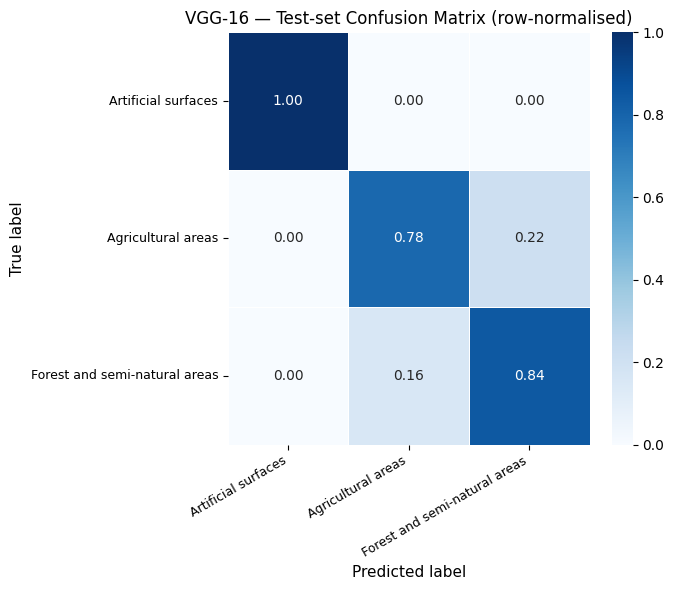

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Level-1 CORINE class names (5 broad categories used in this dataset).
# These match the labels produced by extract_patches_level1.py.
LEVEL1_CLASSES = {
    1: "Artificial surfaces",
    2: "Agricultural areas",
    3: "Forest and semi-natural areas",
    4: "Wetlands",
    5: "Water bodies",
}

# --- Restore the best checkpoint before collecting predictions ---
best_ckpt_path = "/p/scratch/training2600/hilmarsson1/data/training_logs/Model85.ckpt"
print(f"Loading best checkpoint: {best_ckpt_path}")
ckpt = torch.load(best_ckpt_path, map_location="cpu")
model.load_state_dict(ckpt["state_dict"])
model.eval()

# --- Collect test-set predictions ---
y_true_test, y_pred_test = _collect_preds_targets(model, test_dataloader)
labels_arr, cm = _confusion_matrix(y_true_test, y_pred_test)
overall_acc, balanced_acc, macro_f1, recall, precision, f1 = (
    _imbalanced_metrics_from_cm(cm)
)

print("\nTest-set results")
print("-" * 50)
print(f"  Overall Accuracy  : {overall_acc:.4f}")
print(f"  Balanced Accuracy : {balanced_acc:.4f}")
print(f"  Macro-F1          : {macro_f1:.4f}")
print("\nPer-class metrics (idx | support | recall | precision | F1):")
for i, cls in enumerate(labels_arr):
    sup  = int(cm[i].sum())
    code = filtered_dataset.reverse_label_mapping[int(cls)]
    name = LEVEL1_CLASSES.get(code, f"Class {code}")
    print(f"  {name:<35s} | {sup:6d} | {recall[i]:.3f} | "
          f"{precision[i]:.3f} | {f1[i]:.3f}")

# --- Build tick labels using Level-1 names ---
# reverse_label_mapping converts internal index (0-3) → original Level-1
# CORINE code (1-5); LEVEL1_CLASSES maps that code to a human name.
tick_labels = []
for lbl in labels_arr:
    code = filtered_dataset.reverse_label_mapping[int(lbl)]
    tick_labels.append(LEVEL1_CLASSES.get(code, f"Class {code}"))

# --- Row-normalise so each row sums to 1 (recall per class) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=tick_labels,
    yticklabels=tick_labels,
    linewidths=0.5,
    ax=ax,
)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.set_title("VGG-16 — Test-set Confusion Matrix (row-normalised)", fontsize=12)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

# --- Save ---
cm_path = DATA_ROOT / "training_logs" / "confusion_matrix_vgg16.png"
cm_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
print(f"\nConfusion matrix saved → {cm_path}")
plt.show()

## Summary

This notebook demonstrated:

1. **Transformer Architecture**: Built a multi-layer transformer with self-attention for remote sensing classification
2. **CNN Architecture**: Built a VGG-16 network for remote sensing classification
3. **PyTorch Lightning**: Simplified training code by separating data, model, and training logic using dedicate PyTorch-Lightning classes.
4. **Data Pipeline**: Custom Dataset, Subset, DataLoader, and DataModule for clean handling of data.

The trained model can classify remote sensing data into 10 land cover categories using transformer-based deep learning.

## Further reading

- **Lightning datamodules**: [Docs](https://lightning.ai/docs/pytorch/stable/data/datamodule.html) | [Code](https://github.com/Lightning-AI/pytorch-lightning/blob/master/src/lightning/pytorch/core/datamodule.py)
- **VGG architecture**: [Paper](https://arxiv.org/abs/1409.1556) | [Code](https://docs.pytorch.org/vision/main/_modules/torchvision/models/vgg.html#VGG16_Weights)
- **Early stopping**: [Article](https://www.geeksforgeeks.org/machine-learning/regularization-by-early-stopping/)